# Semantic Search in Natural Language Documents

In [ ]:
# for management of your local secrets and configuration parameters
!pip install python-dotenv

In [ ]:
# open-source Python framework based on PyTorch and Hugging Face Transformers
!pip install -U sentence-transformers

Natural language provides a huge part of the information we operate with, so it cannot be excluded for business analysis. <br>
Though, it requires specific preprocessing, at the end of which paragraphs, sentences, and essential words are properly digitalised - __embedded__. The text embedding represents not only dry facts about the lexical, but the semantic meaning, as well. The parts of the speach are encoded by a large vector of numbers, which reflect on the context and the intended meaning of it.<br>
So, the search queries do not return response, based on key words, but on semantic similarity.<br>
Here is the procedure.

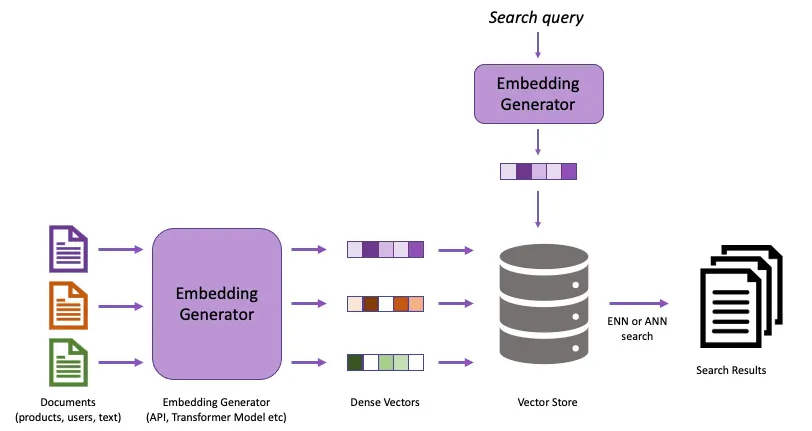

## Import Libraries

In [ ]:
import pandas as pd
import json
# from pydantic import BaseModel, Field

# from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
# from sklearn.metrics import classification_report
# from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

In [ ]:
# for help of open-source LLMs
from langchain_ollama import OllamaEmbeddings
from langchain_ollama.llms import OllamaLLM
from langchain_core.prompts import ChatPromptTemplate

In [ ]:
# for text pre-processing
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.vectorstores import InMemoryVectorStore

In [ ]:
from sentence_transformers import SentenceTransformer, CrossEncoder

In [ ]:
import pandas as pd
import numpy as np

### Local Environment

In [ ]:
# to read my .env variables, .env is a hidden file (dict) in the local work directory
import os
from dotenv import load_dotenv

In [ ]:
# reads the .env file and sets the variables in os.environ
load_dotenv() 

# Now you can securely read them using os.getenv()
test = os.getenv('A')
test

In [ ]:
!ollama list

In [ ]:
!ollama pull qwen3-embedding:0.6b

## Load Data

In [ ]:
# history of Danish movies
# uri = '/Users/tdi/Documents/GitHub/foxdocs/dat-bi/Data/danish_actors.csv'
uri = '/Users/tdi/Documents/GitHub/foxdocs/dat-bi/Data/danish_movies.csv'

In [ ]:
dfm = pd.read_csv(uri)
dfm.shape

In [ ]:
dfm.sample(5)

In [ ]:
dfm.info()

In [ ]:
# filter three attributes only
df = dfm.filter(['title', 'overview', 'popularity'])
df.head()

In [ ]:
# see the full description of one movie
df.iloc[0, 1]

In [ ]:
# missing the overview
df.isna().sum()

In [ ]:
# drop the empty rows
df = df.dropna()

In [ ]:
df.shape

## Text Embedding

In [ ]:
# loading embedding model
model = SentenceTransformer("all-MiniLM-L6-v2")

There are multiple pre-trained embedding models. We work with open source high quality models from 
__HuggingFace__ and __Ollama__. Here are some to choose from: 
- __all-MiniLM-L6-v2__ for speed
- __bert-large-nli-stsb-mean-tokens__ for high accuracy <br>
- __embeddinggemma__ (Google)
- __qwen3-embedding__ (Ali Baba)

### Test the Model on Dummy Data
to see how it works

In [ ]:
# Test the model on some random sentences 
sentences = [
    "The weather is lovely today.",
    "It's so sunny outside!",
    "He drove to the stadium.",
]

In [ ]:
# calculate embedding vectors by calling model.encode()
embeddings = model.encode(sentences, show_progress_bar=True)
embeddings

In [ ]:
embeddings.shape

In [ ]:
# calculate the similarities between the embeddings
similarities = model.similarity(embeddings, embeddings)
similarities

Tere is semantic similarity between the first and second sentences - 0.66. We can visualise that in a scatter plot. See example below.

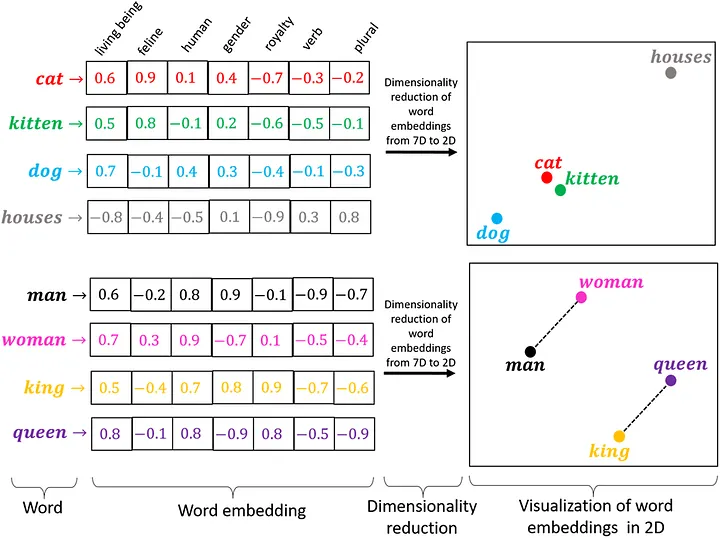

### Apply Embedding Model on Movie Data
Create new column with the embeddings

In [ ]:
# takes some time
df['embed'] = df['overview'].apply(lambda x: model.encode(x))

In [ ]:
df.head()

## Similarity Search

Use our data to train a ML model searching for K-Nearest Neighbors (K is the number of neighbors we search for).

In [ ]:
# Use cosine similarity method to measute the distance between two vectors from the column 'embed'
knn = NearestNeighbors(n_neighbors=5, metric="cosine")
knn.fit(np.array(df.embed.tolist()))

Once we have the trained model (the object _knn_) we can apply it for search similarity between any two texts.<br>
We will use it for comparing a __query text__ with all embedded texts in a search for the best match.<br>
The query needs embedding, too.

In [ ]:
def semantic_search(query, k):
    # embed the search query with the same model, as all the texts
    query_embed = model.encode([query])
    
    # find k nearest neighbors by searching for minimal distances and remmembering their indeces
    distances, indices = knn.kneighbors(query_embed, n_neighbors=k)    

    # call another functioin to print results
    print_results(indices[0], distances[0])
    
    return

In [ ]:
def print_results(indices, distances):
    print(f"\nQuery: '{query}'")
    print("-" * 50)
    
    for i in range(len(indices)):
        idx = indices[i]
        # Convert cosine distance to similarity (1 - distance)
        similarity = 1 - distances[i]
    
        print(f"Result {i+1} (Index: {idx}, Similarity: {similarity:.4f})")
        print(f"Movie Title: {df.iloc[int(idx)]['title']}")
        print(f"Movie Descr: {df.iloc[int(idx)]['overview']}\n")

### Test the Model
Try semantic search of movies.

In [ ]:
query = 'Movies about kings and queens'

In [ ]:
semantic_search(query, 3)

In [ ]:
query = 'Criminal movies involving teenagers'

In [ ]:
semantic_search(query, 5)

In [ ]:
# all we know about the last movie
dfm.iloc[743,]

## Reference
- https://machinelearningmastery.com/build-semantic-search-with-llm-embeddings/
- https://medium.com/operations-research-bit/build-your-own-semantic-search-web-app-with-sentence-transformers-and-faiss-c304e04ca3c9